# 03 — Modelagem

**Dimensão 5 da rubrica — 20 pontos.** São comparados dois classificadores: Regressão Logística e Random Forest.

## Navegação
- [1. Carregamento e divisão](#model-divisao)
- [2. Seleção dos modelos](#model-selecao)
- [3. Regressão Logística](#model-logistica)
- [4. Random Forest](#model-rf)
- [5. Validação cruzada](#model-cv)
- [6. Comparação](#model-comparacao)
- [7. Salvamento dos artefatos](#model-artefatos)

<a id="model-divisao"></a>
## 1. Carregamento e divisão dos dados

O código carrega dataset_tratado.csv, separa TARGET das variáveis preditoras, remove identificadores disponíveis e cria conjuntos de treino e teste com divisão estratificada.

In [40]:
import pandas as pd
from pathlib import Path
from sklearn.model_selection import train_test_split

# 1. Definir o caminho e carregar o ficheiro processado de forma segura
PROCESSED = Path("../data/processed")
file_path = PROCESSED / "dataset_tratado.csv"

df = pd.read_csv(file_path)
print(f"Dimensão do dataset carregado: {df.shape}")

# 2. Separar as variáveis preditoras (X) da variável alvo (y)
# Garantimos a remoção de colunas de identificação que não possuem poder preditivo
cols_to_drop = [col for col in ['TARGET', 'ID', 'Unnamed: 0'] if col in df.columns]
X = df.drop(columns=cols_to_drop) 
y = df['TARGET']

# 3. Divisão em Treino e Teste (Train-Test Split com estratificação rigorosa)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.30,      
    random_state=42,     
    stratify=y           
)

print(f"\nDimensão dos dados de Treino (X_train): {X_train.shape}")
print(f"Dimensão dos dados de Teste (X_test): {X_test.shape}")

# Validar se a estratificação funcionou perfeitamente
print(f"\nProporção de inadimplência no Treino:\n{(y_train.value_counts(normalize=True) * 100).round(2)}")
print(f"Proporção de inadimplência no Teste:\n{(y_test.value_counts(normalize=True) * 100).round(2)}")

Dimensão do dataset carregado: (36457, 50)

Dimensão dos dados de Treino (X_train): (25519, 48)
Dimensão dos dados de Teste (X_test): (10938, 48)

Proporção de inadimplência no Treino:
TARGET
0    98.31
1     1.69
Name: proportion, dtype: float64
Proporção de inadimplência no Teste:
TARGET
0    98.31
1     1.69
Name: proportion, dtype: float64


**Explicação e leitura dos resultados:** A base possui 36.457 linhas e 50 colunas. Após separar o alvo e remover colunas não preditoras, o treino contém 25.519 registros e 48 features; o teste contém 10.938 registros e as mesmas 48 features. Com test_size=0.30, random_state=42 e stratify=y, as proporções observadas são 98,31% da classe 0 e 1,69% da classe 1 em ambos os conjuntos, arredondadas a duas casas. A estratificação preserva aproximadamente a proporção das classes; não garante ausência de outras formas de viés.

<a id="model-selecao"></a>
## 2. Seleção dos modelos

### 2.1 Alternativas consideradas

Entre os classificadores possíveis para dados tabulares estão árvores de decisão, métodos de Gradient Boosting, SVM, Naive Bayes, Regressão Logística e Random Forest. A lista contextualiza a escolha, mas não indica que todos foram treinados.

### 2.2 Modelos comparados

A comparação executada utiliza a Regressão Logística como referência linear e o Random Forest como modelo baseado em árvores. A seleção permite comparar métricas da classe positiva e a capacidade de ordenação das classes. A importância de variáveis do Random Forest não é explicação causal nem justificativa regulatória individual.

<a id="model-logistica"></a>
## 3. Regressão Logística

### 3.1 Treinamento e avaliação

A Regressão Logística é usada como referência (baseline). StandardScaler é ajustado somente com X_train; os dados de teste são transformados com o escalonador já ajustado. O classificador usa class_weight='balanced' para ponderar as classes durante o ajuste.

In [41]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

# 1. Escalonar os dados (Essencial para modelos lineares como Regressão Logística)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 2. Instanciar o modelo de Regressão Logística com class_weight='balanced' e max_iter maior
modelo_lr = LogisticRegression(
    random_state=42, 
    max_iter=5000, 
    class_weight='balanced',
    solver='lbfgs'
)

# 3. Treinar o modelo com os dados escalonados
modelo_lr.fit(X_train_scaled, y_train)

# 4. Realizar previsões no conjunto de teste
y_pred = modelo_lr.predict(X_test_scaled)
y_proba = modelo_lr.predict_proba(X_test_scaled)[:, 1]

# 5. Avaliar o desempenho do Baseline
print("Matriz de Confusão (Baseline com Dados Escalonados):")
print(confusion_matrix(y_test, y_pred))
print("\nRelatório de Classificação:")
print(classification_report(y_test, y_pred))
print(f"\nROC-AUC Score: {roc_auc_score(y_test, y_proba):.4f}")

Matriz de Confusão (Baseline com Dados Escalonados):
[[6549 4204]
 [  99   86]]

Relatório de Classificação:
              precision    recall  f1-score   support

           0       0.99      0.61      0.75     10753
           1       0.02      0.46      0.04       185

    accuracy                           0.61     10938
   macro avg       0.50      0.54      0.40     10938
weighted avg       0.97      0.61      0.74     10938


ROC-AUC Score: 0.5608


### 3.1.1 Leitura dos resultados

A matriz de confusão é [[6549, 4204], [99, 86]]: 6.549 registros da classe 0 são classificados corretamente; 4.204 registros da classe 0 são classificados como classe 1; 99 registros da classe 1 são classificados como classe 0; e 86 registros da classe 1 são classificados corretamente. O teste contém 10.753 registros da classe 0 e 185 da classe 1.

Para a classe 1, a precisão é aproximadamente 0,02, o recall 0,46 e o F1-score 0,04. A acurácia é 0,61 e a ROC-AUC é 0,5608. A execução não calcula PR-AUC para este modelo. O recall maior que o do Random Forest vem acompanhado de muitos falsos positivos; a seleção não deve se apoiar em uma métrica isolada.

### 3.2 Visualização dos resultados da Regressão Logística

O gráfico apresenta a matriz de confusão e a curva ROC do modelo no conjunto de teste.

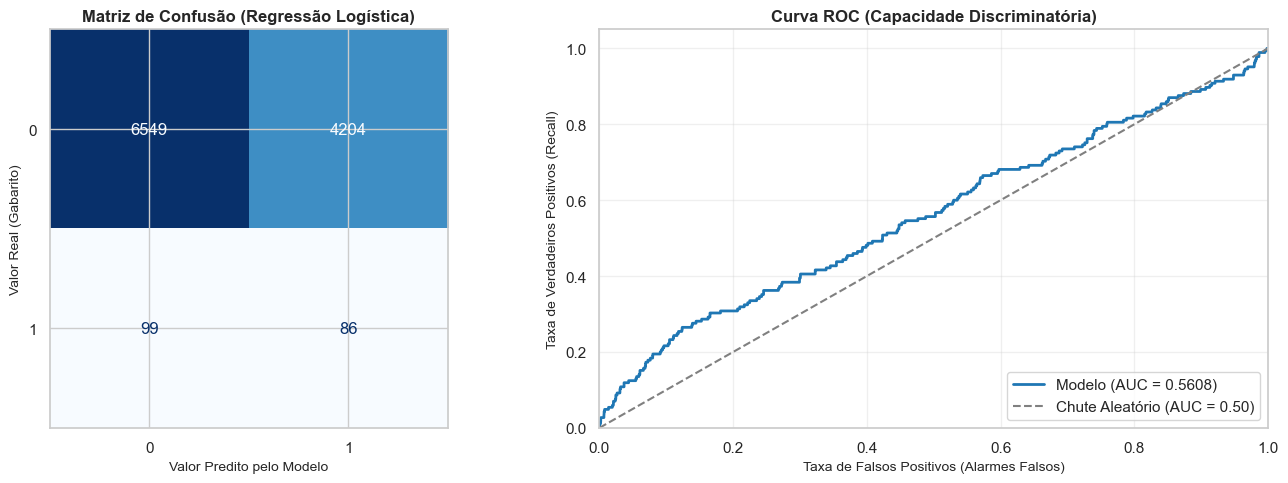

In [42]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import ConfusionMatrixDisplay, roc_curve, auc

# Configurar a área dos gráficos lado a lado
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 1. Gráfico da Matriz de Confusão (Heatmap)
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred, 
    cmap='Blues', 
    ax=axes[0],
    colorbar=False,
    values_format='d'
)
axes[0].set_title('Matriz de Confusão (Regressão Logística)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Valor Predito pelo Modelo', fontsize=10)
axes[0].set_ylabel('Valor Real (Gabarito)', fontsize=10)

# 2. Gráfico da Curva ROC
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

axes[1].plot(fpr, tpr, color='#1f77b4', lw=2, label=f'Modelo (AUC = {roc_auc:.4f})')
axes[1].plot([0, 1], [0, 1], color='gray', linestyle='--', lw=1.5, label='Chute Aleatório (AUC = 0.50)')
axes[1].set_xlim([0.0, 1.0])
axes[1].set_ylim([0.0, 1.05])
axes[1].set_xlabel('Taxa de Falsos Positivos (Alarmes Falsos)', fontsize=10)
axes[1].set_ylabel('Taxa de Verdadeiros Positivos (Recall)', fontsize=10)
axes[1].set_title('Curva ROC (Capacidade Discriminatória)', fontsize=12, fontweight='bold')
axes[1].legend(loc="lower right")
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

**Leitura dos gráficos:** A matriz apresenta 6.549 verdadeiros negativos, 4.204 falsos positivos, 99 falsos negativos e 86 verdadeiros positivos. Os números correspondem à saída da célula de treinamento. A curva ROC apresenta AUC de 0,5608, indicando discriminação limitada nesta amostra.

<a id="model-rf"></a>
## 4. Random Forest

O Random Forest combina árvores e permite capturar relações não lineares. O código ajusta um pipeline com StandardScaler e RandomForestClassifier; o escalonador está encapsulado no pipeline, mas não é necessário para árvores. O classificador usa class_weight='balanced'.

Matriz de Confusão (Random Forest):
[[10451   302]
 [  129    56]]

Relatório de Classificação (Random Forest):
              precision    recall  f1-score   support

           0     0.9878    0.9719    0.9798     10753
           1     0.1564    0.3027    0.2063       185

    accuracy                         0.9606     10938
   macro avg     0.5721    0.6373    0.5930     10938
weighted avg     0.9737    0.9606    0.9667     10938


ROC-AUC Score (Random Forest): 0.6681
PR-AUC Score (Random Forest): 0.1045


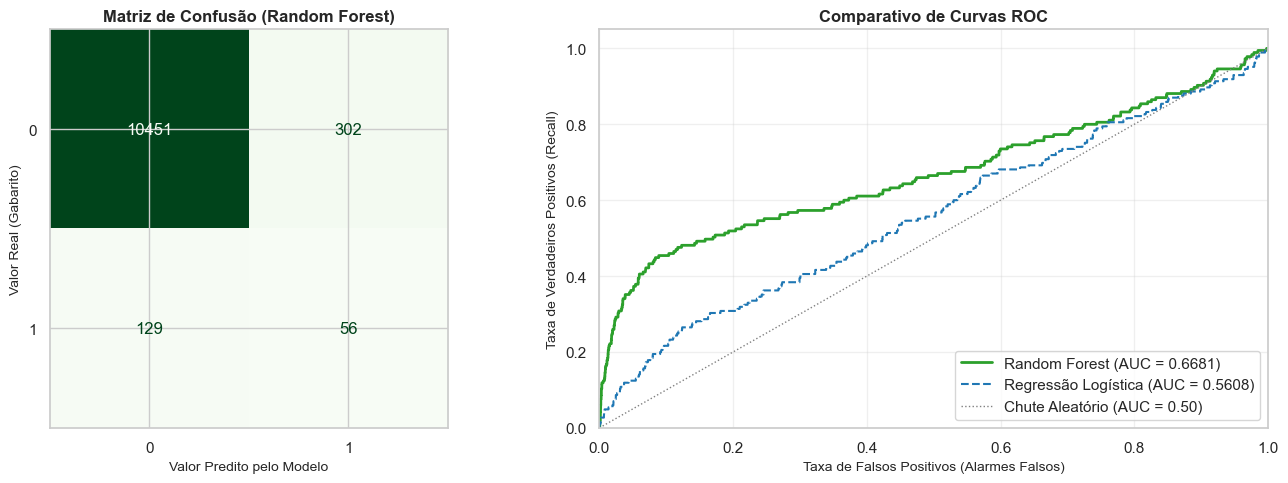

In [43]:
# Random Forest (Floresta Aleatória) com Pipeline e Gráficos Comparativos
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, precision_recall_curve, ConfusionMatrixDisplay, roc_curve, auc
import matplotlib.pyplot as plt

# 1. Construir o Pipeline unindo o escalonamento e o Random Forest
pipeline_rf = Pipeline([
    ('scaler', StandardScaler()),
    ('model', RandomForestClassifier(
        n_estimators=200,
        max_depth=12,
        min_samples_split=10,
        class_weight='balanced',
        random_state=42,
        n_jobs=-1
    ))
])

# 2. Treinar o Pipeline exclusivamente com os dados de treino
pipeline_rf.fit(X_train, y_train)

# 3. Gerar previsões na base de teste isolada
y_pred_rf = pipeline_rf.predict(X_test)
y_prob_rf = pipeline_rf.predict_proba(X_test)[:, 1] # Probabilidade de ser mau pagador

# 4. Avaliar o desempenho do Random Forest
print("Matriz de Confusão (Random Forest):")
print(confusion_matrix(y_test, y_pred_rf))
print("\nRelatório de Classificação (Random Forest):")
print(classification_report(y_test, y_pred_rf, digits=4))

# Cálculo das métricas
roc_auc_rf = roc_auc_score(y_test, y_prob_rf)
precision_rf, recall_rf, _ = precision_recall_curve(y_test, y_prob_rf)
pr_auc_rf = auc(recall_rf, precision_rf)

print(f"\nROC-AUC Score (Random Forest): {roc_auc_rf:.4f}")
print(f"PR-AUC Score (Random Forest): {pr_auc_rf:.4f}")

# 5. Gerar Gráficos Comparativos (Matriz de Confusão e Curva ROC)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Matriz de Confusão RF
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_rf, 
    cmap='Greens', 
    ax=axes[0],
    colorbar=False,
    values_format='d'
)
axes[0].set_title('Matriz de Confusão (Random Forest)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Valor Predito pelo Modelo', fontsize=10)
axes[0].set_ylabel('Valor Real (Gabarito)', fontsize=10)

# Curva ROC RF vs Regressão Logística
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob_rf)
axes[1].plot(fpr_rf, tpr_rf, color='#2ca02c', lw=2, label=f'Random Forest (AUC = {roc_auc_rf:.4f})')

# Reaproveita a curva ROC do baseline calculada anteriormente (assegure-se de que fpr e tpr da reg. logística existam na memória)
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_prob) 
axes[1].plot(fpr_lr, tpr_lr, color='#1f77b4', lw=1.5, linestyle='--', label=f'Regressão Logística (AUC = {roc_auc_lr:.4f})')

axes[1].plot([0, 1], [0, 1], color='gray', linestyle=':', lw=1, label='Chute Aleatório (AUC = 0.50)')
axes[1].set_xlim([0.0, 1.0])
axes[1].set_ylim([0.0, 1.05])
axes[1].set_xlabel('Taxa de Falsos Positivos (Alarmes Falsos)', fontsize=10)
axes[1].set_ylabel('Taxa de Verdadeiros Positivos (Recall)', fontsize=10)
axes[1].set_title('Comparativo de Curvas ROC', fontsize=12, fontweight='bold')
axes[1].legend(loc="lower right")
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

### 4.1 Leitura dos resultados do Random Forest

A matriz de confusão é [[10451, 302], [129, 56]]. Para a classe 1, a precisão é 0,1564, o recall é 0,3027 e o F1-score é 0,2063. A acurácia é 0,9606, a ROC-AUC é 0,6681 e a PR-AUC é 0,1045. Em comparação com a Regressão Logística, o modelo identifica menos casos da classe 1 no limiar padrão, mas gera menos falsos positivos. Os resultados não demonstram prontidão para uso operacional.

### 4.2 Tratamento do desbalanceamento

A classe 1 representa cerca de 1,69% da população de modelagem. Um classificador que previsse todos os registros como classe 0 teria acurácia próxima de 98,31%, mas recall zero para a classe 1. Por esse motivo, os dois classificadores usam class_weight='balanced', que altera os pesos das classes durante o ajuste. A configuração não garante a identificação de todos os inadimplentes nem elimina a necessidade de avaliar precisão, recall e custos de decisão. Não são aplicados SMOTE nem undersampling.

<a id="model-cv"></a>
## 5. Validação cruzada

A validação estratificada divide os dados de treino em cinco partições e preserva aproximadamente a proporção das classes. As métricas são calculadas nas partições de validação; a análise complementa o teste retido, mas não comprova desempenho em populações futuras.

In [44]:
from sklearn.model_selection import cross_validate, StratifiedKFold
import pandas as pd
import numpy as np

# 1. Configurando a validação cruzada estratificada (5 partições)
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# 2. Definindo as métricas de avaliação (foco na classe minoritária)
scoring = ['recall', 'f1', 'roc_auc']

# Dicionário para armazenar os resultados temporariamente
resultados_cv = {}

# 3. Executando para a Regressão Logística 
print("Executando Validação Cruzada para Regressão Logística...")
cv_log_reg = cross_validate(pipeline_lr, X_train, y_train, cv=skf, scoring=scoring, return_train_score=False)
resultados_cv['Regressão Logística'] = cv_log_reg

# 4. Executando para o Random Forest (CORRIGIDO: utilizando o pipeline_rf)
print("Executando Validação Cruzada para Random Forest...")
cv_rf = cross_validate(pipeline_rf, X_train, y_train, cv=skf, scoring=scoring, return_train_score=False)
resultados_cv['Random Forest'] = cv_rf

# 5. Função para compilar e formatar os resultados em uma tabela legível
def compilar_resultados_cv(resultados_dict):
    linhas = []
    for modelo, cv_results in resultados_dict.items():
        linha = {
            'Modelo': modelo,
            'Recall (Média)': np.mean(cv_results['test_recall']),
            'Recall (Desvio Padrão)': np.std(cv_results['test_recall']),
            'ROC-AUC (Média)': np.mean(cv_results['test_roc_auc']),
            'ROC-AUC (Desvio Padrão)': np.std(cv_results['test_roc_auc']),
            'F1-Score (Média)': np.mean(cv_results['test_f1'])
        }
        linhas.append(linha)
    return pd.DataFrame(linhas)

# Gerando a tabela comparativa
df_resultados_cv = compilar_resultados_cv(resultados_cv)
display(df_resultados_cv)

Executando Validação Cruzada para Regressão Logística...
Executando Validação Cruzada para Random Forest...


,Modelo,Recall (Média),Recall (Desvio Padrão),ROC-AUC (Média),ROC-AUC (Desvio Padrão),F1-Score (Média)
0,Regressão Logística,0.505827,0.041598,0.583558,0.026157,0.041434
1,Random Forest,0.338679,0.022576,0.712821,0.042050,0.243733


**Leitura dos resultados:** Na validação cruzada de cinco partições, a Regressão Logística apresenta recall médio de 0,5058 (desvio padrão de 0,0416), ROC-AUC média de 0,5836 e F1 médio de 0,0414. O Random Forest apresenta recall médio de 0,3387 (desvio padrão de 0,0226), ROC-AUC média de 0,7128 e F1 médio de 0,2437.

A Regressão Logística obtém recall médio maior; o Random Forest obtém ROC-AUC e F1 médios maiores. O Random Forest é encaminhado à avaliação final com base nas métricas priorizadas, sem afirmar superioridade em todos os critérios. Os parâmetros registrados são n_estimators=200, max_depth=12 e class_weight='balanced'; não foi realizada busca sistemática para otimizá-los.

<a id="model-comparacao"></a>
## 6. Comparação dos modelos

O gráfico reúne as médias de recall, ROC-AUC e F1-score da validação cruzada. A comparação evidencia o compromisso entre identificar a classe minoritária e ordenar as classes.

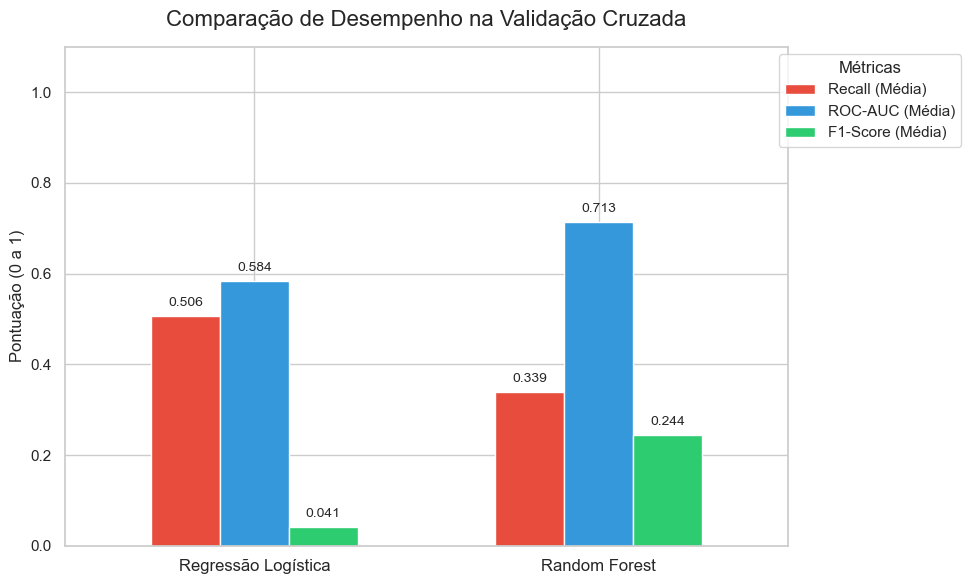

In [45]:
import matplotlib.pyplot as plt
import seaborn as sns

# Preparando os dados para o gráfico usando o DataFrame gerado na etapa 3.4
df_plot = df_resultados_cv[['Modelo', 'Recall (Média)', 'ROC-AUC (Média)', 'F1-Score (Média)']].set_index('Modelo')

# Configurando o estilo do gráfico
sns.set_theme(style="whitegrid")
cores = ['#e74c3c', '#3498db', '#2ecc71'] # Vermelho (Recall), Azul (ROC-AUC), Verde (F1)

# Criando o gráfico de barras
ax = df_plot.plot(kind='bar', figsize=(10, 6), color=cores, width=0.6)

# Customizando títulos e eixos
plt.title('Comparação de Desempenho na Validação Cruzada', fontsize=16, pad=15)
plt.ylabel('Pontuação (0 a 1)', fontsize=12)
plt.xlabel('')
plt.xticks(rotation=0, fontsize=12)
plt.ylim(0, 1.1) # Vai até 1.1 para dar espaço para as anotações
plt.legend(title='Métricas', loc='upper right', bbox_to_anchor=(1.25, 1))

# Adicionando os valores numéricos no topo de cada barra
for p in ax.patches:
    altura = p.get_height()
    if altura > 0: # Evita tentar anotar valores zerados
        ax.annotate(f'{altura:.3f}', 
                    (p.get_x() + p.get_width() / 2., altura), 
                    ha='center', va='bottom', 
                    xytext=(0, 5), 
                    textcoords='offset points',
                    fontsize=10)

plt.tight_layout()
plt.show()

**Leitura do gráfico:** A Regressão Logística apresenta recall médio maior (50,6% contra 33,9%). O Random Forest apresenta ROC-AUC média maior (0,7128 contra 0,5836) e F1 médio maior (0,2437 contra 0,0414). A escolha do Random Forest para a avaliação final reflete a prioridade atribuída à ROC-AUC e ao F1; a Regressão Logística permanece superior em recall médio.

<a id="model-artefatos"></a>
## 7. Salvamento dos artefatos

A célula seguinte salva as partições de teste e o pipeline do Random Forest para uso na avaliação. São artefatos intermediários gerados pelo código, não dados versionados.

In [46]:
import joblib
from pathlib import Path

# Garantindo que a pasta processed existe
caminho_processed = Path("../data/processed")
caminho_processed.mkdir(parents=True, exist_ok=True)

# Salvando os dados de teste em CSV
X_test.to_csv(caminho_processed / "X_test.csv", index=False)
y_test.to_csv(caminho_processed / "y_test.csv", index=False)

# Salvando o pipeline completo (scaler + modelo) para garantir consistência em produção
joblib.dump(pipeline_rf, caminho_processed / "modelo_rf_vencedor.pkl")

print("Pipeline do Random Forest guardado com sucesso para a pasta 'processed'!")

Pipeline do Random Forest guardado com sucesso para a pasta 'processed'!


**Explicação do salvamento:** O código cria o diretório de dados processados, grava X_test.csv e y_test.csv sem índices e persiste o pipeline em modelo_rf_vencedor.pkl. A mensagem de saída confirma o salvamento do pipeline. Esses artefatos permitem que o Notebook 04 avalie o mesmo modelo e a mesma amostra de teste sem refazer o treinamento nessa etapa.